In [1]:
import os
import re
import time
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from deep_translator import GoogleTranslator

In [2]:
# Download required NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

True

In [3]:
df_electronics = pd.read_csv('../data/NLP Sentiment Analysis - Electronics.csv')
df_electronics.head()

,review_id,platform,product_name,category,subcategory,star_rating,review_text,sentiment
0,E001,Shopee,1600W Peak Power HiFi Sound Amplifier Digital ...,Electronics,Speaker,5,barag dh sampai dengn baik comel pawer buyi po...,Neutral
1,E002,Shopee,SPRISE Bass Stereo Portable Bluetooth Speaker ...,Electronics,Speaker,2,Performance:good\n Quality:superb\n \n Small b...,Neutral
2,E003,Shopee,SPRISE Bass Stereo Portable Bluetooth Speaker ...,Electronics,Speaker,2,Bluetooth asik disconnect. Guna aux ada bunyi ...,Negative
3,E004,Shopee,SPRISE Bass Stereo Portable Bluetooth Speaker ...,Electronics,Speaker,2,Quality:Padan la dgn harga\n \n Charging Cable...,Neutral
4,E005,Shopee,SPRISE Bass Stereo Portable Bluetooth Speaker ...,Electronics,Speaker,2,Quality:Sound quality is 7/10..\n \n The suppl...,Negative


In [4]:
df_beauty = pd.read_csv('../data/NLP Sentiment Analysis - Beauty.csv')
df_beauty.head()

,review_id,platform,product_name,category,subcategory,star_rating,review_text,sentiment,Unnamed: 8,Unnamed: 9
0,B001,Shopee,Kiehl's Ultra Facial Cream,Beauty,Skin Care,5,"My skin feels soft, hydrated, and just healthi...",Positive,NaN,"subcategories: skincare, haircare, makeup, bod..."
1,B002,Shopee,Kiehl's Ultra Facial Cream,Beauty,Skin Care,5,Been using this for years and skin looks healt...,Positive,NaN,NaN
2,B003,Shopee,Beauty of Joseon Rice Glow Moisturizing Cream,Beauty,Skin Care,5,It made my skin feels soft & smooth after i ap...,Positive,NaN,NaN
3,B004,Shopee,La Roche Posay Cicaplast Baume B5+,Beauty,Skin Care,1,Develop burning sensation redness and itchy af...,Negative,NaN,NaN
4,B005,Shopee,SKIN1004 Madagascar Centella Soothing Cream Cr...,Beauty,Skin Care,5,My acne has improved a lot after using this,Positive,NaN,NaN


In [5]:
# remove Unamed: 8 and Unnamed: 9 columns in beauty dataset
df_beauty.drop(columns=['Unnamed: 8', 'Unnamed: 9'], inplace=True)

# display new beauty dataset
df_beauty.head()

,review_id,platform,product_name,category,subcategory,star_rating,review_text,sentiment
0,B001,Shopee,Kiehl's Ultra Facial Cream,Beauty,Skin Care,5,"My skin feels soft, hydrated, and just healthi...",Positive
1,B002,Shopee,Kiehl's Ultra Facial Cream,Beauty,Skin Care,5,Been using this for years and skin looks healt...,Positive
2,B003,Shopee,Beauty of Joseon Rice Glow Moisturizing Cream,Beauty,Skin Care,5,It made my skin feels soft & smooth after i ap...,Positive
3,B004,Shopee,La Roche Posay Cicaplast Baume B5+,Beauty,Skin Care,1,Develop burning sensation redness and itchy af...,Negative
4,B005,Shopee,SKIN1004 Madagascar Centella Soothing Cream Cr...,Beauty,Skin Care,5,My acne has improved a lot after using this,Positive


In [6]:
df_fashion = pd.read_csv('../data/NLP Sentiment Analysis - Fashion.csv')
df_fashion.head()

,review_id,time_stamp,platform,product_name,category,subcategory,star_rating,review_text,sentiment,Unnamed: 9
0,FA001,NaN,Shopee,Bella Women Korean Style Suspender Long Dress ...,Fashion,Dress,5,Fits perfectly\r,Positive,NaN
1,FA002,NaN,Shopee,Bella Women Korean Style Suspender Long Dress ...,Fashion,Dress,3,Disappointed because at the back got stained a...,Negative,NaN
2,FA003,NaN,Shopee,Women's Korean Fashion Narrow Waist Slim Fit S...,Fashion,Dress,5,This dress is very nice and fit to my body com...,Positive,NaN
3,FA004,NaN,Shopee,Women's Korean Fashion Narrow Waist Slim Fit S...,Fashion,Dress,1,Hard cloth tough fabric Not fit,Negative,NaN
4,FA005,NaN,Shopee,Women's Korean retro simple Hepburn style wais...,Fashion,Dress,5,"Very beautiful, satisfied, satisfied with the ...",Positive,NaN


In [7]:
# remove timestamp and Unnamed: 9 columns in fashion dataset
df_fashion.drop(columns=['time_stamp', 'Unnamed: 9'], inplace=True)

# display new fashion dataset
df_fashion.head()

,review_id,platform,product_name,category,subcategory,star_rating,review_text,sentiment
0,FA001,Shopee,Bella Women Korean Style Suspender Long Dress ...,Fashion,Dress,5,Fits perfectly\r,Positive
1,FA002,Shopee,Bella Women Korean Style Suspender Long Dress ...,Fashion,Dress,3,Disappointed because at the back got stained a...,Negative
2,FA003,Shopee,Women's Korean Fashion Narrow Waist Slim Fit S...,Fashion,Dress,5,This dress is very nice and fit to my body com...,Positive
3,FA004,Shopee,Women's Korean Fashion Narrow Waist Slim Fit S...,Fashion,Dress,1,Hard cloth tough fabric Not fit,Negative
4,FA005,Shopee,Women's Korean retro simple Hepburn style wais...,Fashion,Dress,5,"Very beautiful, satisfied, satisfied with the ...",Positive


In [8]:
df_food = pd.read_csv('../data/NLP Sentiment Analysis - Food.csv')
df_food.head()

,review_id,platform,product_name,category,subcategory,star_rating,review_text,sentiment
0,FD006,Shopee,NESTLE Milo Activ-Go HCL2.0 1.8kg,Food,Milk and Chocolate Drink,5,"deliciously aromatic and fresh, top notch qual...",Positive
1,FD007,Shopee,NESTLE Milo Activ-Go HCL2.0 1.8kg,Food,Milk and Chocolate Drink,5,Great taste. Excellent quality. This is my num...,Positive
2,FD008,Shopee,NESTLE Milo Activ-Go HCL2.0 1.8kg,Food,Milk and Chocolate Drink,5,The item was superior. Packaging was matchless...,Positive
3,FD009,Shopee,NESTLE Milo Activ-Go HCL2.0 1.8kg,Food,Milk and Chocolate Drink,5,Good quality. Good taste. Thank you very much ...,Positive
4,FD010,Shopee,NESTLE Milo Activ-Go HCL2.0 1.8kg,Food,Milk and Chocolate Drink,5,Good quality. Good taste. Very happy with the ...,Positive


Combine all 4 CSVs into master dataset

In [9]:
# combine all datasets into one
df = pd.concat([df_electronics, df_beauty, df_fashion, df_food], ignore_index=True)
df.head()

,review_id,platform,product_name,category,subcategory,star_rating,review_text,sentiment
0,E001,Shopee,1600W Peak Power HiFi Sound Amplifier Digital ...,Electronics,Speaker,5,barag dh sampai dengn baik comel pawer buyi po...,Neutral
1,E002,Shopee,SPRISE Bass Stereo Portable Bluetooth Speaker ...,Electronics,Speaker,2,Performance:good\n Quality:superb\n \n Small b...,Neutral
2,E003,Shopee,SPRISE Bass Stereo Portable Bluetooth Speaker ...,Electronics,Speaker,2,Bluetooth asik disconnect. Guna aux ada bunyi ...,Negative
3,E004,Shopee,SPRISE Bass Stereo Portable Bluetooth Speaker ...,Electronics,Speaker,2,Quality:Padan la dgn harga\n \n Charging Cable...,Neutral
4,E005,Shopee,SPRISE Bass Stereo Portable Bluetooth Speaker ...,Electronics,Speaker,2,Quality:Sound quality is 7/10..\n \n The suppl...,Negative


In [10]:
df.tail()

,review_id,platform,product_name,category,subcategory,star_rating,review_text,sentiment
607,FD142,Lazada,Wheatsun Buckwheat Noodles,Food,Noodles & Pasta,1,some are broken..must pack properly,Negative
608,FD147,Lazada,MEWAH White Rice 1kg,Food,Rice,1,The item packaging already cut open upon arriv...,Negative
609,FD148,Lazada,MEWAH White Rice 1kg,Food,Rice,1,parcel not delivered but status delivered !!! ...,Negative
610,FD149,Lazada,MEWAH White Rice 1kg,Food,Rice,1,I have successfully completed the game and rec...,Negative
611,FD150,Lazada,MEWAH White Rice 1kg,Food,Rice,1,"The gift pack of rice is torn, the rice appear...",Negative


Dataframe Summary

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 612 entries, 0 to 611
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   review_id     612 non-null    str  
 1   platform      612 non-null    str  
 2   product_name  612 non-null    str  
 3   category      612 non-null    str  
 4   subcategory   612 non-null    str  
 5   star_rating   612 non-null    int64
 6   review_text   612 non-null    str  
 7   sentiment     612 non-null    str  
dtypes: int64(1), str(7)
memory usage: 38.4 KB


Remove Duplicate Rows

In [12]:
# remove duplicates
df.drop_duplicates(inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 612 entries, 0 to 611
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   review_id     612 non-null    str  
 1   platform      612 non-null    str  
 2   product_name  612 non-null    str  
 3   category      612 non-null    str  
 4   subcategory   612 non-null    str  
 5   star_rating   612 non-null    int64
 6   review_text   612 non-null    str  
 7   sentiment     612 non-null    str  
dtypes: int64(1), str(7)
memory usage: 38.4 KB


EDA

C:\Users\insyi\AppData\Local\Temp\ipykernel_31936\3403646426.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='category', data=df, palette=['lightgray', 'lightblue', 'lightcoral', 'lightgreen'])


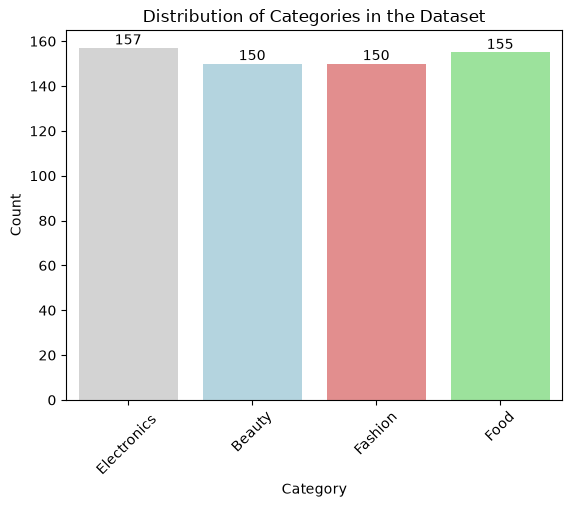

In [13]:
# show the distribution of each category in the dataset with 4 different colors
ax = sns.countplot(x='category', data=df, palette=['lightgray', 'lightblue', 'lightcoral', 'lightgreen'])
plt.title('Distribution of Categories in the Dataset')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
for i, bar in enumerate(ax.patches):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1, f'{int(bar.get_height())}', ha='center', va='bottom')
plt.show()

C:\Users\insyi\AppData\Local\Temp\ipykernel_31936\2599829228.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='sentiment', data=df, palette=['lightcoral', 'lightgray', 'lightgreen'])


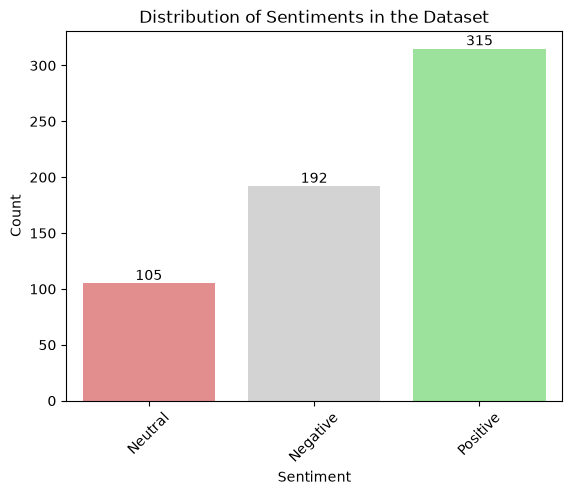

In [14]:
# shows the distribution of each sentiment in the dataset
ax = sns.countplot(x='sentiment', data=df, palette=['lightcoral', 'lightgray', 'lightgreen'])
plt.title('Distribution of Sentiments in the Dataset')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=45)
for i, bar in enumerate(ax.patches):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1, f'{int(bar.get_height())}', ha='center', va='bottom')
plt.show()

Step 1: Convert Slang/Shortform to Standard Language

In [15]:
slang_dict = {
    # =========================
    # BASIC SHORT FORMS
    # =========================
    'x': 'tidak',
    'tak': 'tidak',
    'takde': 'tidak ada',
    'xde': 'tidak ada',
    'xtau': 'tidak tahu',
    'xpe': 'tidak apa',
    'xboleh': 'tidak boleh',
    'xbole': 'tidak boleh',
    'dah': 'sudah',
    'dh': 'sudah',
 
    'sy': 'saya',
    'aq': 'saya',
    'ak': 'saya',
 
    'u': 'you',
    'ur': 'your',
 
    # =========================
    # CONNECTORS / FILLERS
    # =========================
    'dgn': 'dengan',
    'dengn': 'dengan',
    'ngn': 'dengan',
    '&': 'dan',
    'n': 'dan',
 
    'tp': 'tetapi',
    'tpi': 'tetapi',
    'tapi': 'tetapi',
 
    'je': 'sahaja',
    'jer': 'sahaja',
 
    'ni': 'ini',
    'tu': 'itu',
    'kt': 'dekat',
 
    'yg': 'yang',
    'utk': 'untuk',
 
    'sbb': 'sebab',
    'sb': 'sebab',
 
    'pastu': 'selepas itu',
    'pastuh': 'selepas itu',
 
    # =========================
    # QUANTITY / TIME
    # =========================
    'bape': 'berapa',
    'brp': 'berapa',
 
    'lame': 'lama',
    'lamer': 'lama',
 
    'jgk': 'juga',
    'juga': 'juga',
 
    # =========================
    # PRODUCT TERMS
    # =========================
    'brg': 'barang',
    'barag': 'barang',
    'barang2': 'barang-barang',
 
    'buyi': 'bunyi',
    'bnyi': 'bunyi',
    'bunyii': 'bunyi',
 
    'gune': 'guna',
    'pakai': 'guna',
 
    'rm': 'ringgit',
    'qty': 'quantity',
 
    # =========================
    # QUALITY / CONDITION WORDS
    # =========================
    'ok': 'okay',
    'okayy': 'okay',
    'okey': 'okay',
 
    'btol': 'betul',
    'betui': 'betul',
 
    'rengan': 'ringan',
    'berat2': 'berat',
 
    'asik': 'asyik',
    'asyik2': 'asyik',
 
    'sgt': 'sangat',
    'sangat2': 'sangat',
 
    # =========================
    # FOUND IN DATASET
    # =========================
    # Malay words / expressions
    'mmg': 'memang',
    'memang': 'memang',
    'mcm': 'macam',
    'mcm2': 'macam-macam',
    'mkin': 'makin',
    'makin': 'makin',
    'kdg': 'kadang',
    'kdg2': 'kadang-kadang',
    'lncr': 'lancar',
    'tgk': 'tengok',
    'tgok': 'tengok',
    'blh': 'boleh',
    'bole': 'boleh',
    'dlm': 'dalam',
    'drpd': 'daripada',
    'drp': 'daripada',
    'kat': 'dekat',
    'nk': 'mahu',
    'nak': 'mahu',
    'dpt': 'dapat',
    'dpt2': 'dapat-dapat',
    'xdpt': 'tidak dapat',
    'harap2': 'harap-harap',
    'mantapp': 'mantap',
    'mantappp': 'mantap',
    'best': 'best',
    'bestla': 'best',
    'lawa': 'cantik',
    'hampeh': 'hampa',
    'hampa': 'hampa',
 
    # Mixed English-Malay
    'superb': 'superb',
    'powerfull': 'powerful',
    'pawer': 'power',
 
    # Common chat abbreviations found in dataset
    'wayer': 'wayar',
    'cas': 'charge',
    'caj': 'charge',
    'bot': 'bought',
    'sumpah': '',        # filler expression
    'la': '',
    'lah': '',
    'leh': '',
    'woo': '',
    'nih': '',
    'wei': '',
    'weh': '',
 
    # =========================
    # EMOTIONAL / EXPRESSIONS
    # =========================
    'haha': '',
    'hahaha': '',
    'hahahha': '',
    'huhu': '',
    'hehe': '',
    'hmm': '',
    'hhm': '',
 
    # =========================
    # ENGLISH MIX / COMMON CHAT
    # =========================
    'pls': 'please',
    'thx': 'thank you',
    'tq': 'thank you',
    'tqvm': 'thank you very much',
    'alr': 'already',
    'tbh': 'to be honest',
    'imo': 'in my opinion',
    'omg': 'oh my god',
    'info': 'information',
    'pic': 'picture',
    'pics': 'pictures',
    'msg': 'message',
    'qty': 'quantity',
    'ori': 'original',
    'orig': 'original',
    'rec': 'recommend',
    'recom': 'recommend',
    'diff': 'different',
    'prob': 'problem',
    'probs': 'problems',
    'def': 'definitely',
    'defo': 'definitely',
    'esp': 'especially',
    'approx': 'approximately',
    'avg': 'average',
    'max': 'maximum',
    'min': 'minimum',
    'btw': 'by the way',
    'fyi': 'for your information',
    'gg': '',
    'lol': '',
    'xd': '',
}

In [16]:
def normalize_slang(text, slang_dict):
    """Replace slang words with their normalized form using word boundary matching."""
    if not isinstance(text, str):
        return text
    words = text.split()
    normalized = [slang_dict.get(word.lower(), word) for word in words]
    # Filter out empty strings (removed filler words)
    return ' '.join([w for w in normalized if w.strip() != ''])
 
print("Applying slang normalization...")
df['review_text_fixed'] = df['review_text'].apply(lambda x: normalize_slang(x, slang_dict))

df[['review_id', 'review_text', 'review_text_fixed']].head()

Applying slang normalization...


,review_id,review_text,review_text_fixed
0,E001,barag dh sampai dengn baik comel pawer buyi po...,barang sudah sampai dengan baik comel power bu...
1,E002,Performance:good\n Quality:superb\n \n Small b...,Performance:good Quality:superb Small but powe...
2,E003,Bluetooth asik disconnect. Guna aux ada bunyi ...,Bluetooth asyik disconnect. Guna aux ada bunyi...
3,E004,Quality:Padan la dgn harga\n \n Charging Cable...,Quality:Padan dengan harga Charging Cable mema...
4,E005,Quality:Sound quality is 7/10..\n \n The suppl...,Quality:Sound quality is 7/10.. The supply don...


Step 2: Translation to English
- use deep-translator

In [17]:
def safe_translate(text, max_length=4500, retries=3, delay=2):
    """Translate text to English with retry logic and chunking for long texts."""
    if not isinstance(text, str) or text.strip() == '':
        return text
    try:
        if len(text) > max_length:
            chunks = [text[i:i+max_length] for i in range(0, len(text), max_length)]
            translated_chunks = []
            for chunk in chunks:
                for attempt in range(retries):
                    try:
                        translated_chunks.append(
                            GoogleTranslator(source='auto', target='en').translate(chunk)
                        )
                        time.sleep(delay)
                        break
                    except Exception:
                        if attempt < retries - 1:
                            time.sleep(delay * 2)
                        else:
                            translated_chunks.append(chunk)
            return ' '.join(translated_chunks)
 
        for attempt in range(retries):
            try:
                result = GoogleTranslator(source='auto', target='en').translate(text)
                time.sleep(0.5)
                return result
            except Exception:
                if attempt < retries - 1:
                    time.sleep(delay * 2)
                else:
                    return text
    except Exception as e:
        print(f"Translation failed: {e}")
        return text
 
df['review_text_translated'] = df['review_text_fixed'].apply(safe_translate)

# Preview
df[['review_id', 'review_text_fixed', 'review_text_translated']].head()

,review_id,review_text_fixed,review_text_translated
0,E001,barang sudah sampai dengan baik comel power bu...,"The item has arrived well, it's cute, the powe..."
1,E002,Performance:good Quality:superb Small but powe...,Performance:good Quality:superb Small but powe...
2,E003,Bluetooth asyik disconnect. Guna aux ada bunyi...,Bluetooth keeps disconnecting. Use aux there i...
3,E004,Quality:Padan dengan harga Charging Cable mema...,Quality: Matches the price of the Charging Cab...
4,E005,Quality:Sound quality is 7/10.. The supply don...,Quality:Sound quality is 7/10.. The supply don...


In [18]:
df.head()

,review_id,platform,product_name,category,subcategory,star_rating,review_text,sentiment,review_text_fixed,review_text_translated
0,E001,Shopee,1600W Peak Power HiFi Sound Amplifier Digital ...,Electronics,Speaker,5,barag dh sampai dengn baik comel pawer buyi po...,Neutral,barang sudah sampai dengan baik comel power bu...,"The item has arrived well, it's cute, the powe..."
1,E002,Shopee,SPRISE Bass Stereo Portable Bluetooth Speaker ...,Electronics,Speaker,2,Performance:good\n Quality:superb\n \n Small b...,Neutral,Performance:good Quality:superb Small but powe...,Performance:good Quality:superb Small but powe...
2,E003,Shopee,SPRISE Bass Stereo Portable Bluetooth Speaker ...,Electronics,Speaker,2,Bluetooth asik disconnect. Guna aux ada bunyi ...,Negative,Bluetooth asyik disconnect. Guna aux ada bunyi...,Bluetooth keeps disconnecting. Use aux there i...
3,E004,Shopee,SPRISE Bass Stereo Portable Bluetooth Speaker ...,Electronics,Speaker,2,Quality:Padan la dgn harga\n \n Charging Cable...,Neutral,Quality:Padan dengan harga Charging Cable mema...,Quality: Matches the price of the Charging Cab...
4,E005,Shopee,SPRISE Bass Stereo Portable Bluetooth Speaker ...,Electronics,Speaker,2,Quality:Sound quality is 7/10..\n \n The suppl...,Negative,Quality:Sound quality is 7/10.. The supply don...,Quality:Sound quality is 7/10.. The supply don...


Step 2: Text Cleaning
- Convert to lowercase
- Remove URLs
- Remove emojis
- Remove punctuation
- Remove repeated characters (e.g. "goood" → "good")
- Remove Stopword (the, is, and, a, to)
- Remove extra whitespaces

In [19]:
from nltk.corpus import stopwords

# columns to clean
text_cols = ['platform', 'product_name', 'category', 'subcategory', 'review_text_translated', 'sentiment']

# Emoji pattern
emoji_pattern = re.compile("["
    u"\U0001F600-\U0001F64F"
    u"\U0001F300-\U0001F5FF"
    u"\U0001F680-\U0001F6FF"
    u"\U0001F1E0-\U0001F1FF"
    u"\U00002700-\U000027BF"
    u"\U0001F900-\U0001F9FF"
    u"\U00002500-\U00002BEF"
"]+", flags=re.UNICODE)

In [20]:
# 1. Lowercase
for col in text_cols:
    df[col] = df[col].str.lower()

# 2. Remove URLs
for col in text_cols:
    df[col] = df[col].str.replace(r'http\S+|www\S+', '', regex=True)

# 3. Remove emojis
for col in text_cols:
    df[col] = df[col].apply(
        lambda x: emoji_pattern.sub('', x) if isinstance(x, str) else x
    )

# 4. Convert X/Y rating format to "X out of Y"
for col in text_cols:
    df[col] = df[col].apply(
        lambda x: re.sub(r'(\d+)\s*/\s*(\d+)', r'\1 out of \2', x) if isinstance(x, str) else x
    )

# 5. Replace colons with space (e.g. "Performance:good" -> "Performance good")
for col in text_cols:
    df[col] = df[col].str.replace(r'[:]', ' ', regex=True)

# 6. Remove punctuation exclude /
for col in text_cols:
    df[col] = df[col].str.replace(r'[^\w\s/]', '', regex=True)

# 7. Remove repeated characters (e.g. "goood" -> "good")
for col in text_cols:
    df[col] = df[col].apply(
        lambda x: re.sub(r'(.)\1{2,}', r'\1', x) if isinstance(x, str) else x
    )

# 8. Remove stopwords
stop_words = set(stopwords.words('english'))
for col in text_cols:
    df[col] = df[col].apply(
        lambda x: ' '.join([w for w in x.split() if w not in stop_words])
        if isinstance(x, str) else x
    )

# 9. Remove extra whitespace
for col in text_cols:
    df[col] = df[col].str.strip().str.replace(r'\s+', ' ', regex=True)

df.head()

,review_id,platform,product_name,category,subcategory,star_rating,review_text,sentiment,review_text_fixed,review_text_translated
0,E001,shopee,1600w peak power hifi sound amplifier digital ...,electronics,speaker,5,barag dh sampai dengn baik comel pawer buyi po...,neutral,barang sudah sampai dengan baik comel power bu...,item arrived well cute power good sound even l...
1,E002,shopee,sprise bass stereo portable bluetooth speaker ...,electronics,speaker,2,Performance:good\n Quality:superb\n \n Small b...,neutral,Performance:good Quality:superb Small but powe...,performance good quality superb small powerful...
2,E003,shopee,sprise bass stereo portable bluetooth speaker ...,electronics,speaker,2,Bluetooth asik disconnect. Guna aux ada bunyi ...,negative,Bluetooth asyik disconnect. Guna aux ada bunyi...,bluetooth keeps disconnecting use aux noise fe...
3,E004,shopee,sprise bass stereo portable bluetooth speaker ...,electronics,speaker,2,Quality:Padan la dgn harga\n \n Charging Cable...,neutral,Quality:Padan dengan harga Charging Cable mema...,quality matches price charging cable isnt real...
4,E005,shopee,sprise bass stereo portable bluetooth speaker ...,electronics,speaker,2,Quality:Sound quality is 7/10..\n \n The suppl...,negative,Quality:Sound quality is 7/10.. The supply don...,quality sound quality 7 10 supply dont even bo...


Step 3: Normalization (POS Lemmatization)
-  reduces words to their base/root form so different variations of the same word are treated as one

In [21]:
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')  # for newer NLTK versions

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\insyi\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\insyi\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [22]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk import pos_tag, word_tokenize

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [23]:
lemmatizer = WordNetLemmatizer()

def lemmatize_text_pos(text):
    if not isinstance(text, str):
        return text

    tokens = word_tokenize(text)
    pos_tags = pos_tag(tokens)

    lemmatized = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in pos_tags
    ]

    return ' '.join(lemmatized)

df['review_text_normalized'] = df['review_text_translated'].apply(lemmatize_text_pos)

In [24]:
df[['review_id', 'review_text_translated', 'review_text_normalized']].head()

,review_id,review_text_translated,review_text_normalized
0,E001,item arrived well cute power good sound even l...,item arrive well cute power good sound even la...
1,E002,performance good quality superb small powerful...,performance good quality superb small powerful...
2,E003,bluetooth keeps disconnecting use aux noise fe...,bluetooth keep disconnect use aux noise feel l...
3,E004,quality matches price charging cable isnt real...,quality match price charge cable isnt really h...
4,E005,quality sound quality 7 10 supply dont even bo...,quality sound quality 7 10 supply dont even bo...


Step 4: Tokenization
-  splits a sentence into individual word units (tokens) that the model can process

In [25]:
from nltk.tokenize import word_tokenize

df['review_tokens'] = df['review_text_normalized'].apply(
    lambda x: word_tokenize(x) if isinstance(x, str) else []
)
print("Tokenization complete.")
print(f"\nSample tokens:\n{df['review_tokens'].head(3)}")

Tokenization complete.

Sample tokens:
0    [item, arrive, well, cute, power, good, sound,...
1    [performance, good, quality, superb, small, po...
2    [bluetooth, keep, disconnect, use, aux, noise,...
Name: review_tokens, dtype: object


Step 5: Data Splitting - train (70%), validation (15%), and test (15%)

In [26]:
# First split: 70% train, 30% temp
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df['sentiment'])
 
# Second split: 50% of temp = 15% validation, 50% = 15% test
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['sentiment'])
 
print(f"\nData split:")
print(f"  Train : {len(train_df)} rows ({len(train_df)/len(df)*100:.1f}%)")
print(f"  Val   : {len(val_df)} rows  ({len(val_df)/len(df)*100:.1f}%)")
print(f"  Test  : {len(test_df)} rows  ({len(test_df)/len(df)*100:.1f}%)")
 
# Add split label to master dataframe
df['split'] = 'train'
df.loc[val_df.index, 'split'] = 'val'
df.loc[test_df.index, 'split'] = 'test'


Data split:
  Train : 428 rows (69.9%)
  Val   : 92 rows  (15.0%)
  Test  : 92 rows  (15.0%)


Step 6: Saved reviews_master_clean.csv

In [27]:
output_path = '../data/master_clean.csv'
df.to_csv(output_path, index=False)
print(f"\nSaved cleaned dataset to: {output_path}")
print(f"Final shape: {df.shape}")

df.head()


Saved cleaned dataset to: ../data/master_clean.csv
Final shape: (612, 13)


,review_id,platform,product_name,category,subcategory,star_rating,review_text,sentiment,review_text_fixed,review_text_translated,review_text_normalized,review_tokens,split
0,E001,shopee,1600w peak power hifi sound amplifier digital ...,electronics,speaker,5,barag dh sampai dengn baik comel pawer buyi po...,neutral,barang sudah sampai dengan baik comel power bu...,item arrived well cute power good sound even l...,item arrive well cute power good sound even la...,"[item, arrive, well, cute, power, good, sound,...",test
1,E002,shopee,sprise bass stereo portable bluetooth speaker ...,electronics,speaker,2,Performance:good\n Quality:superb\n \n Small b...,neutral,Performance:good Quality:superb Small but powe...,performance good quality superb small powerful...,performance good quality superb small powerful...,"[performance, good, quality, superb, small, po...",val
2,E003,shopee,sprise bass stereo portable bluetooth speaker ...,electronics,speaker,2,Bluetooth asik disconnect. Guna aux ada bunyi ...,negative,Bluetooth asyik disconnect. Guna aux ada bunyi...,bluetooth keeps disconnecting use aux noise fe...,bluetooth keep disconnect use aux noise feel l...,"[bluetooth, keep, disconnect, use, aux, noise,...",train
3,E004,shopee,sprise bass stereo portable bluetooth speaker ...,electronics,speaker,2,Quality:Padan la dgn harga\n \n Charging Cable...,neutral,Quality:Padan dengan harga Charging Cable mema...,quality matches price charging cable isnt real...,quality match price charge cable isnt really h...,"[quality, match, price, charge, cable, isnt, r...",test
4,E005,shopee,sprise bass stereo portable bluetooth speaker ...,electronics,speaker,2,Quality:Sound quality is 7/10..\n \n The suppl...,negative,Quality:Sound quality is 7/10.. The supply don...,quality sound quality 7 10 supply dont even bo...,quality sound quality 7 10 supply dont even bo...,"[quality, sound, quality, 7, 10, supply, dont,...",test


In [28]:
# Test step 4 on a sample
test = "Sound quality is 7/10"
print(re.sub(r'(\d+)/(\d+)', r'\1 out of \2', test))
# Expected: "Sound quality is 7 out of 10"

Sound quality is 7 out of 10
